# Improving Blurbs with LLMs

**Research question:** Can LLM-rewritten blurbs increase the predicted probability of crowdfunding success?


## Loading the Team's Data & Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
from collections import Counter
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from safetensors.torch import load_file

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import textstat
import spacy
import google.generativeai as genai

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

nlp = spacy.load("en_core_web_md")
sentiment_analyzer = SentimentIntensityAnalyzer()

print("All libraries loaded.")

All libraries loaded.


In [3]:
#Load pre-engineered data (feature_engineering.py)
df_train = pd.read_csv("data/features/train.csv")
df_val = pd.read_csv("data/features/val.csv")
df_test = pd.read_csv("data/features/test.csv")

#Load feature lists
with open("data/features/features_scale.txt") as f:
    features_scale = [line.strip() for line in f.readlines()]
with open("data/features/features_no_scale.txt") as f:
    features_no_scale = [line.strip() for line in f.readlines()]

all_features = features_scale + features_no_scale

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")
print(f"Features to scale ({len(features_scale)}): {features_scale}")
print(f"Features no scale ({len(features_no_scale)}): {features_no_scale}")

Train: 66,096 | Val: 22,032 | Test: 22,033
Features to scale (8): ['duration', 'CCI_index', 'blurb_length', 'sentiment_score', 'readability_score', 'name_blurb_similarity', 'log_goal', 'CCI_per_goal']
Features no scale (21): ['cat_Art', 'cat_Comics', 'cat_Crafts', 'cat_Dance', 'cat_Design', 'cat_Fashion', 'cat_Film & Video', 'cat_Food', 'cat_Games', 'cat_Journalism', 'cat_Music', 'cat_Photography', 'cat_Publishing', 'cat_Technology', 'cat_Theater', 'country_AU', 'country_CA', 'country_GB', 'country_NZ', 'country_US', 'z-score_log_goal']


In [ ]:
# Load joint BERT model 
class DistilBERTWithStructuredFeatures(nn.Module):
    def __init__(self, model_name, structured_dim, num_labels=2, dropout=0.2, hidden_dim=256):
        super().__init__()
        self.text_encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        text_hidden_size = self.text_encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(text_hidden_size + structured_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_labels),
        )
    
    @staticmethod
    def mean_pooling(last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
    
    def forward(self, input_ids, attention_mask, structured_features):
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.mean_pooling(outputs.last_hidden_state, attention_mask)
        pooled = self.dropout(pooled)
        combined = torch.cat([pooled, structured_features], dim=1)
        return self.classifier(combined)


# Prepare the scaler 
bert_scaler = StandardScaler()
bert_scaler.fit(df_train[features_scale].astype(np.float32).values)

# Load the joint BERT model
BERT_CHECKPOINT = "LLM/joint_distilbert_structured_results/checkpoint-16524"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

bert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = DistilBERTWithStructuredFeatures(
    model_name="distilbert-base-uncased",
    structured_dim=len(features_scale) + len(features_no_scale),
)

# Load weights
state = load_file(f"{BERT_CHECKPOINT}/model.safetensors")
bert_model.load_state_dict(state, strict=True)
bert_model.to(device)
bert_model.eval()

print("BERT model loaded — using joint text+structured (ROC-AUC 0.857 on val set)")

Device: cpu


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded — using joint text+structured (ROC-AUC 0.857 on val set)


## 1. What Textual Patterns Drive Success?

We already captured sentiment, readability, and name-blurb similarity. Here we go deeper into the text itself to understand what to write in a blurb:

- Which specific words are most associated with success vs. failure? (TF-IDF)
- Do call-to-action words make a measurable difference?
- How do the NLP features differ between successful and failed campaigns?

These insights will directly inform our LLM rewriting prompt.

### NLP Features: Successful vs. Failed Campaigns

Using the features already computed, we statistically compare the two groups.

,Feature,Mean (Successful),Mean (Failed),Difference,t-statistic,p-value,Significant
0,blurb_length,22.333,22.628,-0.295,-17.99,4.00e-72,***
1,sentiment_score,0.298,0.349,-0.051,-14.39,7.10e-47,***
2,readability_score,59.065,60.715,-1.651,-11.84,2.80e-32,***
3,name_blurb_similarity,0.694,0.672,+0.022,14.76,3.36e-49,***


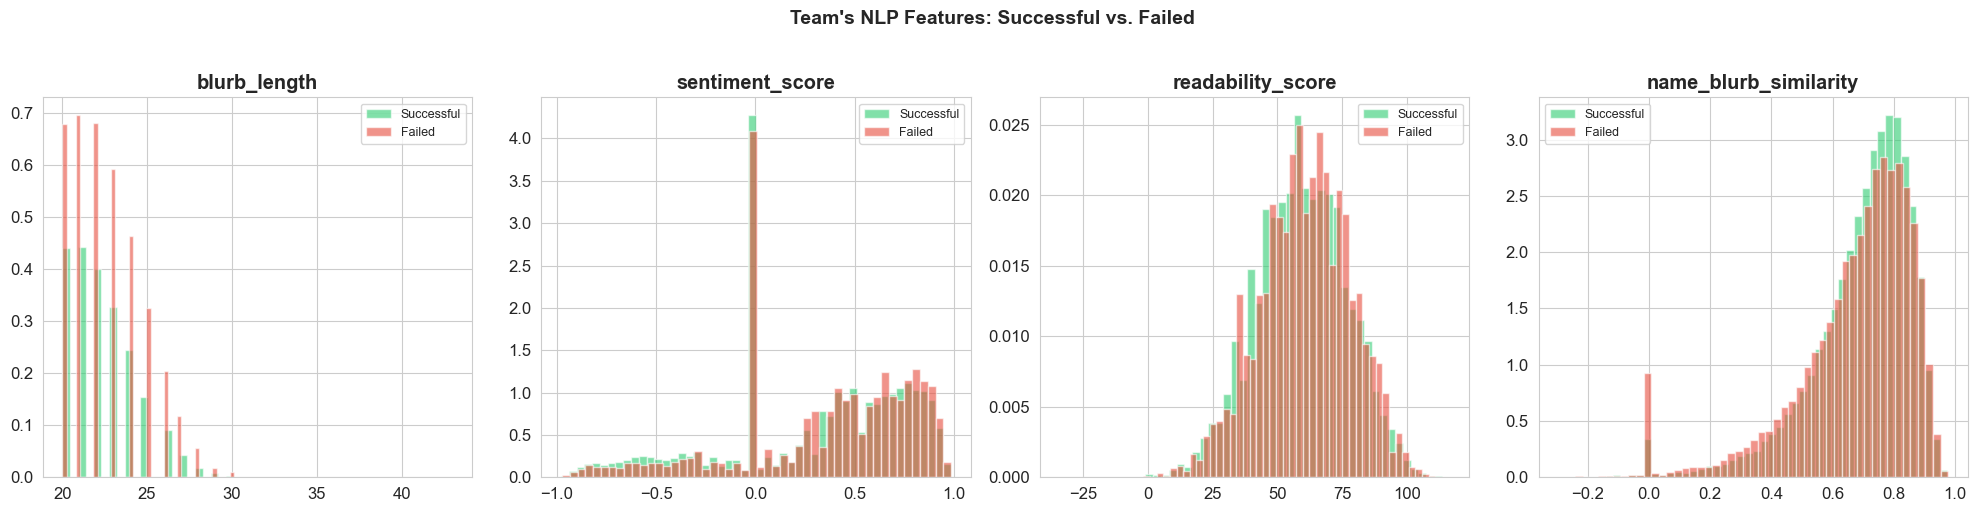

In [6]:
#Statistical comparison of text features 
text_feat_cols = ['blurb_length', 'sentiment_score', 'readability_score', 'name_blurb_similarity']

comparison = []
for col in text_feat_cols:
    succ = df_train[df_train['target'] == 1][col].dropna()
    fail = df_train[df_train['target'] == 0][col].dropna()
    t_stat, p_val = stats.ttest_ind(succ, fail, equal_var=False)
    comparison.append({
        'Feature': col,
        'Mean (Successful)': f"{succ.mean():.3f}",
        'Mean (Failed)': f"{fail.mean():.3f}",
        'Difference': f"{succ.mean() - fail.mean():+.3f}",
        't-statistic': f"{t_stat:.2f}",
        'p-value': f"{p_val:.2e}",
        'Significant': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'No'))
    })

display(pd.DataFrame(comparison))

#Distributions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(text_feat_cols):
    ax = axes[i]
    df_train[df_train['target'] == 1][col].hist(bins=50, alpha=0.6, label='Successful', color='#2ecc71', ax=ax, density=True)
    df_train[df_train['target'] == 0][col].hist(bins=50, alpha=0.6, label='Failed', color='#e74c3c', ax=ax, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle("Team's NLP Features: Successful vs. Failed", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Discriminative Words (TF-IDF Analysis)

Beyond engineered features, which specific words are most predictive of success vs. failure?

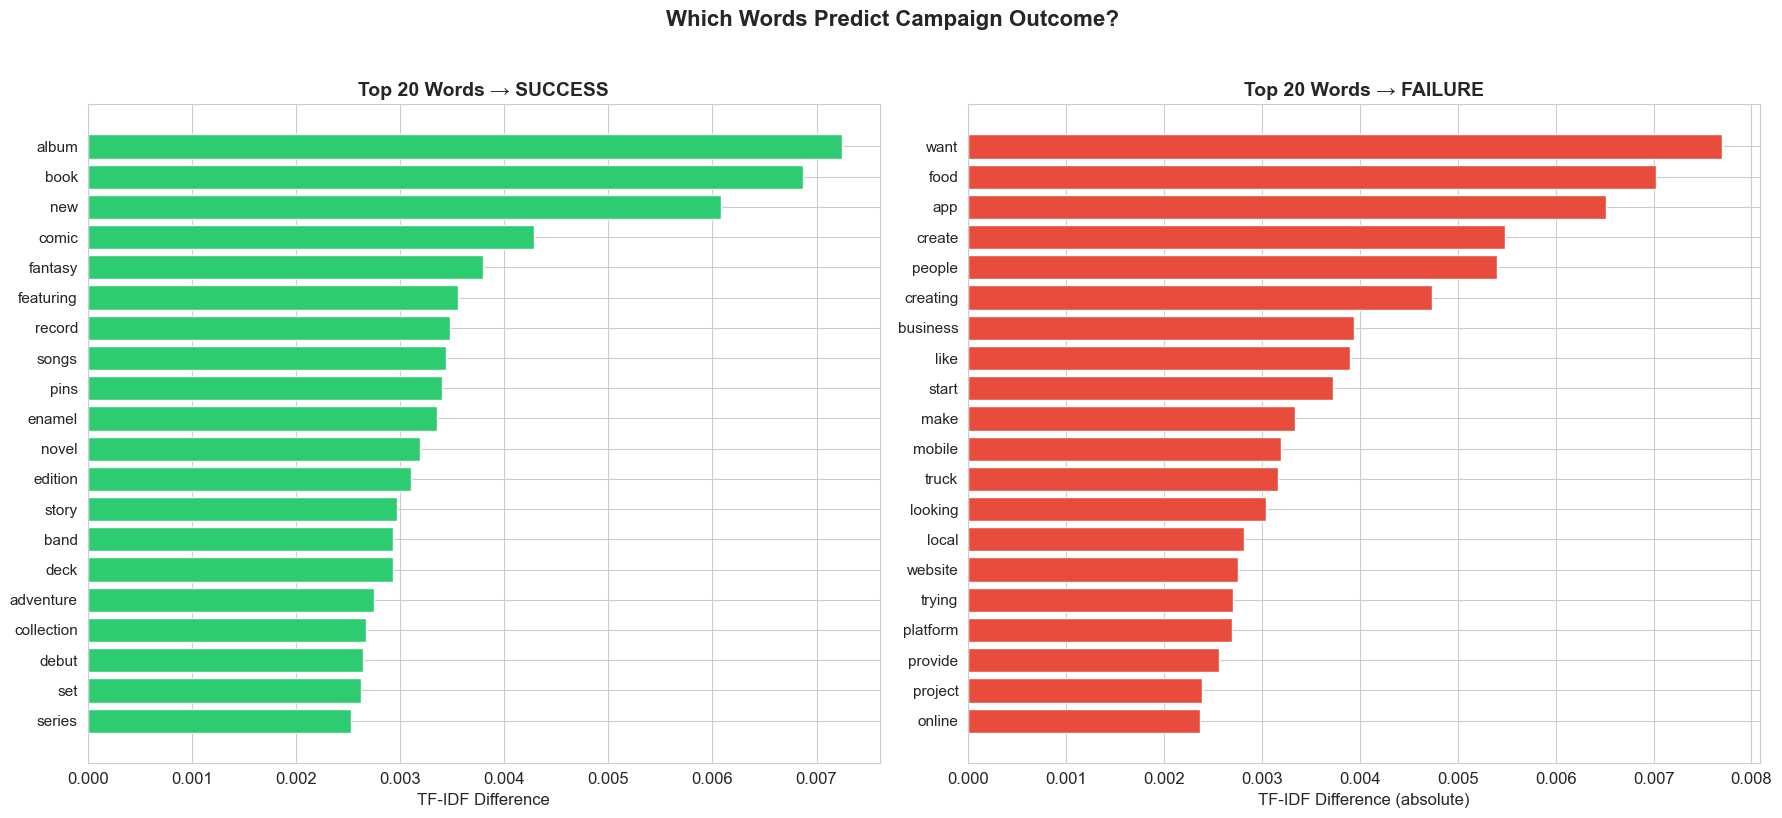

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

#TF-IDF on training blurbs
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', min_df=10, max_df=0.9)
tfidf_matrix = tfidf.fit_transform(df_train['blurb'].fillna(''))
feature_names = tfidf.get_feature_names_out()

#Mean TF-IDF for successful vs failed
succ_mask = df_train['target'] == 1
mean_tfidf_succ = np.array(tfidf_matrix[succ_mask].mean(axis=0)).flatten()
mean_tfidf_fail = np.array(tfidf_matrix[~succ_mask].mean(axis=0)).flatten()
tfidf_diff = mean_tfidf_succ - mean_tfidf_fail

top_success_idx = tfidf_diff.argsort()[-20:][::-1]
top_failure_idx = tfidf_diff.argsort()[:20]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.barh(range(20), tfidf_diff[top_success_idx], color='#2ecc71', edgecolor='white')
ax1.set_yticks(range(20))
ax1.set_yticklabels(feature_names[top_success_idx], fontsize=11)
ax1.set_title("Top 20 Words → SUCCESS", fontweight='bold', fontsize=14)
ax1.set_xlabel("TF-IDF Difference")
ax1.invert_yaxis()

ax2.barh(range(20), abs(tfidf_diff[top_failure_idx]), color='#e74c3c', edgecolor='white')
ax2.set_yticks(range(20))
ax2.set_yticklabels(feature_names[top_failure_idx], fontsize=11)
ax2.set_title("Top 20 Words → FAILURE", fontweight='bold', fontsize=14)
ax2.set_xlabel("TF-IDF Difference (absolute)")
ax2.invert_yaxis()

plt.suptitle("Which Words Predict Campaign Outcome?", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Call-to-Action Words

Do action verbs like "help", "join", "discover" appear more in successful campaigns?

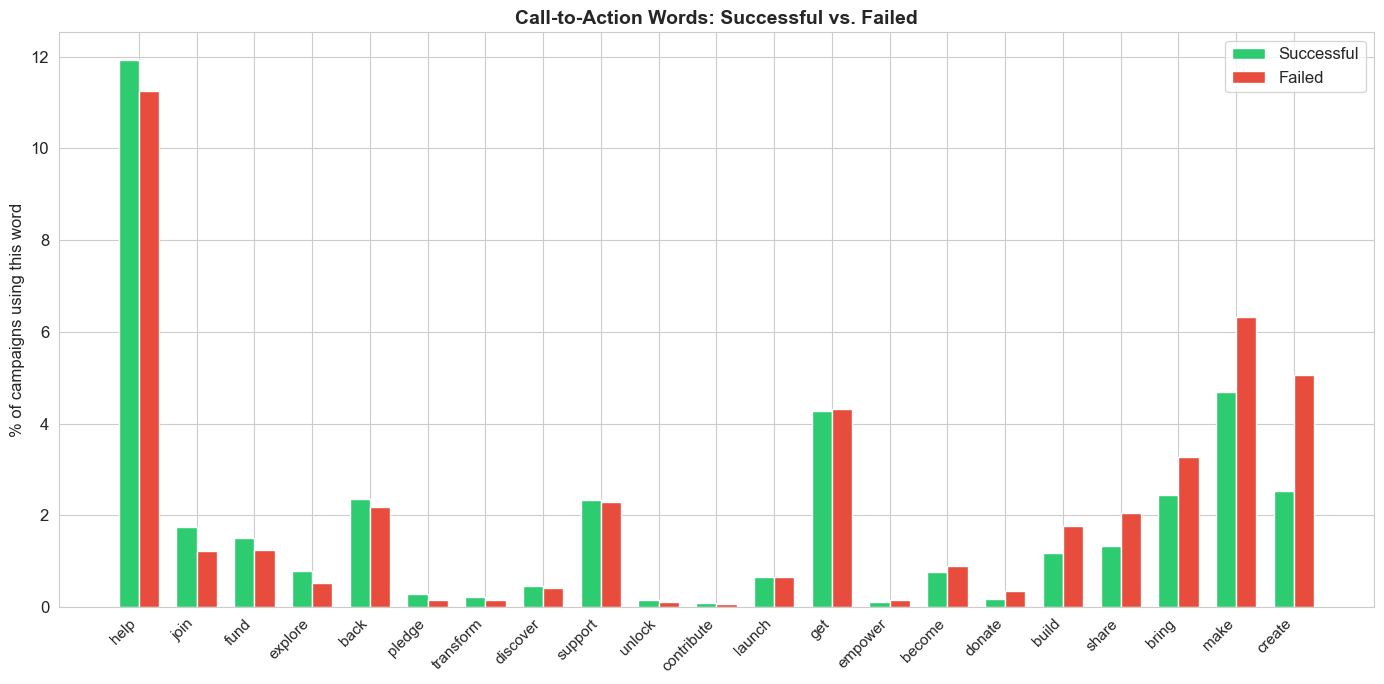

,Word,Successful (%),Failed (%),Lift (pp)
0,help,11.932643,11.259089,0.673554
1,join,1.741480,1.220819,0.520661
2,fund,1.498774,1.236127,0.262647
3,explore,0.778161,0.516648,0.261514
4,back,2.362008,2.177574,0.184434
5,pledge,0.277736,0.145427,0.132309
6,transform,0.220187,0.153081,0.067106
7,discover,0.462893,0.413318,0.049575
8,support,2.329480,2.280903,0.048577
9,unlock,0.145123,0.099502,0.045621


In [8]:
#Call-to-action word analysis
cta_words = ['help', 'join', 'support', 'discover', 'explore', 'back', 'pledge',
             'contribute', 'fund', 'donate', 'share', 'become', 'make', 'create',
             'bring', 'launch', 'build', 'transform', 'empower', 'unlock', 'get']

def count_cta_per_word(blurbs, words):
    counts = Counter()
    for blurb in blurbs:
        tokens = set(re.findall(r'\b\w+\b', str(blurb).lower()))
        for w in words:
            if w in tokens:
                counts[w] += 1
    return counts

succ_blurbs = df_train[df_train['target'] == 1]['blurb']
fail_blurbs = df_train[df_train['target'] == 0]['blurb']
cta_succ = count_cta_per_word(succ_blurbs, cta_words)
cta_fail = count_cta_per_word(fail_blurbs, cta_words)

cta_df = pd.DataFrame({
    'Word': cta_words,
    'Successful (%)': [cta_succ[w] / len(succ_blurbs) * 100 for w in cta_words],
    'Failed (%)': [cta_fail[w] / len(fail_blurbs) * 100 for w in cta_words],
})
cta_df['Lift (pp)'] = cta_df['Successful (%)'] - cta_df['Failed (%)']
cta_df = cta_df.sort_values('Lift (pp)', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(cta_df))
width = 0.35
ax.bar(x - width/2, cta_df['Successful (%)'], width, label='Successful', color='#2ecc71')
ax.bar(x + width/2, cta_df['Failed (%)'], width, label='Failed', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(cta_df['Word'], rotation=45, ha='right', fontsize=11)
ax.set_ylabel("% of campaigns using this word")
ax.set_title("Call-to-Action Words: Successful vs. Failed", fontweight='bold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

display(cta_df.reset_index(drop=True))

## 2. LLM Blurb Rewriting & Evaluation

Can an LLM improve blurbs so they score higher on the prediction model?

We:
1. Build a data-driven rewriting prompt 
2. Sample failed campaigns from the test set and rewrite them with Gemini
3. Re-extract the features for the rewritten blurbs
4. Compare predicted success probabilities before vs. after

In [ ]:
#Configure Gemini
GEMINI_API_KEY = ""
genai.configure(api_key=GEMINI_API_KEY)
gemini_model = genai.GenerativeModel("gemini-2.5-flash")

#Test connection
response = gemini_model.generate_content("Say 'Gemini ready' in exactly 2 words.")
print(f"API connected: {response.text.strip()}")

API connected: Gemini ready


In [10]:
# Data-driven rewriting prompt — informed by our analysis in Section 1
REWRITE_PROMPT = """You are an expert crowdfunding copywriter. Rewrite the blurb below to maximize the campaign's chance of getting funded.

Follow these evidence-based rules (from analysis of 110,000+ Kickstarter campaigns):

1. SENTIMENT: Use positive, enthusiastic language, warm tone but stay natural. Target a VADER compound score between 0.3 and 0.5. Avoid sounding overly promotional or desperate.
2. READABILITY: Use simple, everyday words. Short sentences. Target a Flesch Reading Ease score above 60. Avoid marketing jargon, complex vocabulary, and fancy adjectives.
3. CALL-TO-ACTION: Include 2-3 action verbs: help, join, support, discover, create, build, bring, launch, share, explore.
4. LENGTH: Keep between 20-30 words. Use the simplest phrasing possible. Every word must earn its place.
5. COHERENCE: The blurb must clearly relate to the project name.
6. SPECIFICITY: Be concrete about what the project delivers.
7. EMOTIONAL APPEAL: Convey passion without desperation. "Help us bring X to life" > "We need money for X".
8. SIMPLICITY: Write like you're explaining the project to a friend, not writing an ad.

KEYWORD OPTIMIZATION: Based on the project Category, prioritize the "Top 10 Success Words" and strictly avoid the "Top 10 Failure Words" listed in the reference data below:
- Film & Video: Success (documentary, webseries, stretch, thesis, short, web, complete, blu, refugee, misadventures) | Failure (screenplay, educate, based, want, television, entertainment, tv, anime, experiment, destiny)
- Publishing: Success (children, dragon, magical, featuring, kids, holmes, picture, memoir, hardcover, bestselling) | Failure (poetic, knowledge, podcast, poetry, current, com, sports, magazine, adult, creating)
- Art: Success (coloring, residency, mural, pins, 2013, deck, enamel, book, public, dragons) | Failure (youtube, peace, wood, opportunities, canvas, express, com, want, difference, game)
- Music: Success (folk, heading, rock, collaborative, new, returns, nashville, stretch, bluegrass, hands) | Failure (edm, latin, artist, gospel, equipment, rap, hiphop, im, electronic, showcasing)
- Technology: Success (clock, arduino, auto, raspberry, compact, compatible, waterproof, mac, pen, portable) | Failure (creating, products, app, website, site, platform, owners, application, members, able)

Here are 2 examples of what a blurb in Film & Video category with a high probability of success looks like:
1. "A post-apocalyptic love story with all practical FX. Winner of two Best Feature awards. Get your name in the credits and a signed copy!"
2. "A narrative film following a woman's journey from her home in San Francisco into her family's past at the shores of the Salton Sea."

Here are 2 examples of what a blurb in Film & Video category with a high probability of failure looks like:
1. "This cartoon is about the main character 'PG' Porky/Glenn who tells stories about his life experiences as a child and adult."
2. "the story of in a movie of scam and pozie dealings of a man who was to think that america roads were paved with gold"

Here are 2 examples of what a blurb in Publishing category with a high probability of success looks like:
1. "A zine focused on the stories of magical girls (or boys, etc) fighting against social issues in our dystopian world."
2. "A group of diverse creators bring quests for social change to the magical girl genre and resources to help you join the fight."

Here are 2 examples of what a blurb in Publishing category with a high probability of failure looks like:
1. "Wanting to finish Publishing the last 3 of the book series. Also to have it adapted for Tv mini series."
2. "We aim to make high quality independent music accessible to everyone. Help support emerging artists by giving them a place to be heard"

Here are 2 examples of what a blurb in Art category with a high probability of success looks like:
1. "Time for Art builds into a series of pieces influenced by you, the backers. You control content & duration. This month: cityscape"
2. "Time for Art will build into a series of pieces influenced by you, the backers. You control content & duration. This month: parkland"

Here are 2 examples of what a blurb in Art category with a high probability of failure looks like:
1. "Opening an art Studio with today's technology and current art students for tutoring to every person to access for a small fee."
2. "My name is Mitchell and I make thick or thin framed canvases. I am looking for help to get equipment of my own such as a printer."

Here are 2 examples of what a blurb in Music category with a high probability of success looks like:
1. "Noveria plans to be recording our 2nd album, 'In Silence', this fall. We need money, to do that. Any help would be greatly appreciated."
2. "I've been working with a group of film makers in New York to create a short film for my single 'Know Your Worth'."

Here are 2 examples of what a blurb in Music category with a high probability of failure looks like:
1. "I am creating an internet radio station that caters to those who love and crave the music from the late 80's through mid 2000's."
2. "I wanted to hold a festival with the vendors and day time fun of a off road overlanding expo, with the amazing live rock/edm music."

Here are 2 examples of what a blurb in Technology category with a high probability of success looks like:
1. "Award-Winning Audio Design Experts Voix are back with their latest product. The amazing mi8| Retro Duo Wireless Stereo Sound System."
2. "The perfect holiday gift for your friend that has suddenly become fascinated with flat earth cartography. Or just get one for yourself."

Here are 2 examples of what a blurb in Technology category with a high probability of failure looks like:
1. "I want this city to advance the future in an old world city. and to breathe new life into it."
2. "It is a smart car diagnostic station for each car owner who wants to check his car before going to Dealer garage for repairs."

Output ONLY the rewritten blurb. No explanations, no quotes.

Project Name: {name}
Category: {category}
Original Blurb: {blurb}

Rewritten Blurb:"""


def rewrite_blurb(name, blurb, category, max_retries=3):
    """Rewrite a single blurb using Gemini."""
    prompt = REWRITE_PROMPT.format(name=name, blurb=blurb, category=category)
    for attempt in range(max_retries):
        try:
            response = gemini_model.generate_content(prompt)
            return response.text.strip().strip('"').strip("'")
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f"  Failed after {max_retries} retries: {e}")
                return None

# Quick test
test_rewrite = rewrite_blurb(
    "Das Good Seasonings",
    "Das Good Inc goal is to make cooking easy and delicious with our seasoning and sauces that can be used by everyone!",
    "Food"
)
print(f"Original:  Das Good Inc goal is to make cooking easy and delicious...")
print(f"Rewritten: {test_rewrite}")


Original:  Das Good Inc goal is to make cooking easy and delicious...
Rewritten: Das Good Seasonings offers cooking essentials. Help us launch our sauces and seasonings. Join us to bring them to more kitchens.


In [12]:
#Sample 100 failed campaigns from test set
failed_test = df_test[df_test['target'] == 0]
sample = failed_test.sample(n=100, random_state=42).copy()

#Identify category columns to recover the category name
cat_cols = [c for c in sample.columns if c.startswith('cat_')]

def get_category_name(row):
    for c in cat_cols:
        if row[c] == 1:
            return c.replace('cat_', '')
    return 'General'

sample['category'] = sample.apply(get_category_name, axis=1)

print(f"Sampled {len(sample)} failed campaigns from test set")
print(f"Category distribution:\n{sample['category'].value_counts().head(10)}")

Sampled 100 failed campaigns from test set
Category distribution:
category
Film & Video    17
Food            14
Music           13
Technology      13
Photography     11
Art              9
Publishing       6
Theater          5
Games            5
Crafts           4
Name: count, dtype: int64


In [13]:
#Batch rewrite with Gemini
print("Rewriting 100 blurbs with Gemini")


rewritten = []
for i, (_, row) in enumerate(sample.iterrows()):
    r = rewrite_blurb(row['name'], row['blurb'], row['category'])
    rewritten.append(r)
    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/100] completed")
    time.sleep(0.5)  # rate limiting

sample['rewritten_blurb'] = rewritten
n_ok = sum(1 for r in rewritten if r is not None)
print(f"\n{n_ok}/{len(rewritten)} blurbs successfully rewritten.")

Rewriting 100 blurbs with Gemini
  [10/100] completed
  [20/100] completed
  [30/100] completed
  [40/100] completed
  [50/100] completed
  [60/100] completed
  [70/100] completed
  [80/100] completed
  [90/100] completed
  [100/100] completed

100/100 blurbs successfully rewritten.


In [14]:
# Show examples
examples = sample[sample['rewritten_blurb'].notna()].head(8)
for i, (_, row) in enumerate(examples.iterrows()):
    print(f"\nExample {i+1}: {row['name'][:60]} [{row['category']}]")
    print(f"  Original:  {row['blurb']}")
    print(f"  Rewritten: {row['rewritten_blurb']}")


Example 1: The Announcement [Film & Video]
  Original:  This story is about responsibility, consequences and the damage that can be caused when a position of power is abused.
  Rewritten: Join us to support 'The Announcement,' a powerful short film exploring responsibility and the far-reaching impact of power.

Example 2: Mr Piggly 2D animation [Film & Video]
  Original:  In a trailer on the outskirts of the Nevada desert, Mr Piggly is down and out, but still believes in the American Dream.
  Rewritten: Mr Piggly's 2D animation: discover his short film. Join him, down and out but holding onto the American Dream, as he navigates misadventures.

Example 3: Community Nutritional Food & Education Program [Food]
  Original:  Nature's Bounty Farm, Inc is a non profit organization developed to educate and provide nutritional meals for those in need.
  Rewritten: Help us build our Community Nutritional Food & Education Program. Join us to bring healthy meals and learning to a vibrant, healthi

### Re-extracting Features & Scoring

We re-extract the same 4 text features that we used before (`blurb_length`, `sentiment_score`, `readability_score`, `name_blurb_similarity`) for both original and rewritten blurbs, then re-score with the BERT model.

In [ ]:

def extract_team_features(name, blurb):
    """Extract the 4 text features used in our pipeline."""
    blurb_str = str(blurb)
    name_str = str(name)
    
    blurb_length = len(blurb_str.split())
    sentiment_score = sentiment_analyzer.polarity_scores(blurb_str)['compound']
    readability_score = textstat.flesch_reading_ease(blurb_str)
    
    doc_name = nlp(name_str)
    doc_blurb = nlp(blurb_str)
    name_blurb_similarity = doc_name.similarity(doc_blurb)
    
    return {
        'blurb_length': blurb_length,
        'sentiment_score': sentiment_score,
        'readability_score': readability_score,
        'name_blurb_similarity': name_blurb_similarity
    }

# Filter to valid rewrites
eval_df = sample[sample['rewritten_blurb'].notna()].copy()
print(f"Evaluating {len(eval_df)} campaigns with valid rewrites")

# Extract features for rewritten blurbs
rewr_feats = []
for _, row in eval_df.iterrows():
    rewr_feats.append(extract_team_features(row['name'], row['rewritten_blurb']))
rewr_feat_df = pd.DataFrame(rewr_feats, index=eval_df.index)


Evaluating 100 campaigns with valid rewrites


In [ ]:
# Score with BERT for original and rewritten blurbs
text_features = ["blurb_length", "sentiment_score", "readability_score", "name_blurb_similarity"]


def score_with_bert(name, blurb, row, text_feats=None):
    """Score a (name, blurb) using the joint BERT model with metadata from row."""
    if text_feats is None:
        text_feats = extract_team_features(name, blurb)
    
    # Build structured vector: [21 no-scale] + [8 scale] 
    no_scale_vals = np.array([row[c] for c in features_no_scale], dtype=np.float32)
    scale_raw = {}
    scale_raw["duration"] = row["duration"]
    scale_raw["CCI_index"] = row["CCI_index"]
    scale_raw["blurb_length"] = text_feats["blurb_length"]
    scale_raw["sentiment_score"] = text_feats["sentiment_score"]
    scale_raw["readability_score"] = text_feats["readability_score"]
    scale_raw["name_blurb_similarity"] = text_feats["name_blurb_similarity"]
    scale_raw["log_goal"] = np.log1p(row["goal_usd"])
    scale_raw["CCI_per_goal"] = row["CCI_index"] / max(row["goal_usd"], 1)
    scale_arr = np.array([scale_raw[c] for c in features_scale], dtype=np.float32).reshape(1, -1)
    scale_scaled = bert_scaler.transform(scale_arr).flatten()
    struct = np.concatenate([no_scale_vals, scale_scaled]).astype(np.float32)
    struct = np.nan_to_num(struct, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Tokenize text
    text = f"{name} {blurb}"
    inputs = bert_tokenizer(text, truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    struct_tensor = torch.from_numpy(struct).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = bert_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            structured_features=struct_tensor,
        )
        prob = torch.softmax(logits, dim=-1)[0, 1].item()
    return float(prob)


# Score original and rewritten blurbs
print("Scoring original and rewritten blurbs with BERT...")
prob_orig = []
prob_rewr = []
for idx, row in eval_df.iterrows():
    # Original — use pre-computed features from the CSV row
    orig_feats = {
        "blurb_length": row["blurb_length"],
        "sentiment_score": row["sentiment_score"],
        "readability_score": row["readability_score"],
        "name_blurb_similarity": row["name_blurb_similarity"],
    }
    prob_orig.append(score_with_bert(row["name"], row["blurb"], row, orig_feats))
    
    # Rewritten — re-extracted features
    rewr_feats = rewr_feat_df.loc[idx].to_dict()
    prob_rewr.append(score_with_bert(row["name"], row["rewritten_blurb"], row, rewr_feats))

prob_orig = np.array(prob_orig)
prob_rewr = np.array(prob_rewr)

# Results
lift = prob_rewr - prob_orig
print(f"Mean predicted success probability:")
print(f"  Original blurbs:  {prob_orig.mean():.4f} ({(prob_orig > 0.5).mean():.1%} classified successful)")
print(f"  Rewritten blurbs: {prob_rewr.mean():.4f} ({(prob_rewr > 0.5).mean():.1%} classified successful)")
print(f"  Mean lift:        {lift.mean():+.4f}")
print(f"  Campaigns improved: {(lift > 0).sum()}/{len(lift)} ({(lift > 0).mean():.1%})")
print(f"  Flipped to successful: {((prob_orig < 0.5) & (prob_rewr >= 0.5)).sum()}")

# Paired t-test
t_stat, p_val = stats.ttest_rel(prob_rewr, prob_orig)
print(f"\nPaired t-test: t={t_stat:.3f}, p={p_val:.2e} {'***' if p_val < 0.001 else ''}")

Scoring original and rewritten blurbs with BERT...
Mean predicted success probability:
  Original blurbs:  0.3853 (38.0% classified successful)
  Rewritten blurbs: 0.6467 (71.0% classified successful)
  Mean lift:        +0.2614
  Campaigns improved: 83/100 (83.0%)
  Flipped to successful: 33

Paired t-test: t=7.622, p=1.53e-11 ***


In [18]:
# Feature-level comparison: did each text feature improve?
feat_comparison = []
for col in text_features:
    orig_vals = eval_df[col]
    rewr_vals = rewr_feat_df[col]
    t_stat, p_val = stats.ttest_rel(orig_vals, rewr_vals)
    feat_comparison.append({
        'Feature': col,
        'Original (mean)': f"{orig_vals.mean():.3f}",
        'Rewritten (mean)': f"{rewr_vals.mean():.3f}",
        'Change': f"{rewr_vals.mean() - orig_vals.mean():+.3f}",
        'p-value': f"{p_val:.2e}",
        'Significant': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'No'))
    })

print("Feature-Level Comparison: Original vs. Rewritten Blurbs")
display(pd.DataFrame(feat_comparison))

Feature-Level Comparison: Original vs. Rewritten Blurbs


,Feature,Original (mean),Rewritten (mean),Change,p-value,Significant
0,blurb_length,22.310,21.630,-0.680,4.93e-02,*
1,sentiment_score,0.294,0.739,+0.445,2.23e-15,***
2,readability_score,59.646,57.278,-2.368,1.91e-01,No
3,name_blurb_similarity,0.643,0.686,+0.044,3.15e-07,***


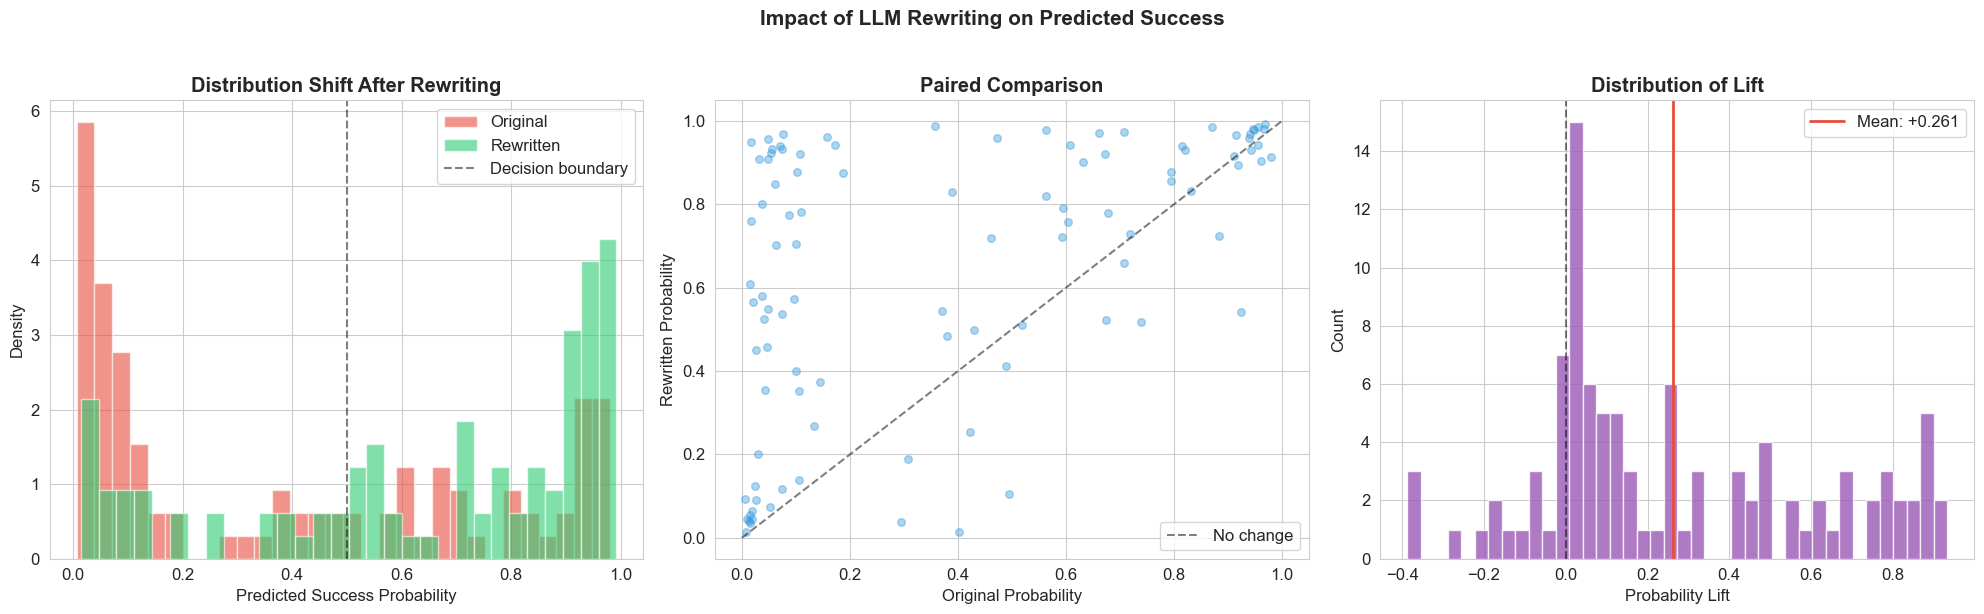

In [19]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#Probability distribution shift
ax = axes[0]
ax.hist(prob_orig, bins=30, alpha=0.6, label='Original', color='#e74c3c', density=True)
ax.hist(prob_rewr, bins=30, alpha=0.6, label='Rewritten', color='#2ecc71', density=True)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Decision boundary')
ax.set_xlabel("Predicted Success Probability")
ax.set_ylabel("Density")
ax.set_title("Distribution Shift After Rewriting", fontweight='bold')
ax.legend()

#Paired scatter
ax = axes[1]
ax.scatter(prob_orig, prob_rewr, alpha=0.4, s=30, color='#3498db')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='No change')
ax.set_xlabel("Original Probability")
ax.set_ylabel("Rewritten Probability")
ax.set_title("Paired Comparison", fontweight='bold')
ax.legend()

#Lift distribution
ax = axes[2]
ax.hist(lift, bins=40, color='#9b59b6', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.axvline(lift.mean(), color='#e74c3c', linewidth=2, label=f'Mean: {lift.mean():+.3f}')
ax.set_xlabel("Probability Lift")
ax.set_ylabel("Count")
ax.set_title("Distribution of Lift", fontweight='bold')
ax.legend()

plt.suptitle("Impact of LLM Rewriting on Predicted Success", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Live Demo

The audience writes a project proposal, and the pipeline:
1. Scores the blurb's predicted success probability
2. Highlights strengths and weaknesses
3. Generates specific recommendations
4. Rewrites the blurb with Gemini
5. Shows the before/after comparison

In [24]:
def score_blurb_demo(name, blurb, category, country="US", goal_usd=10000, duration=30, cci_index=100.0):
    """Score a blurb using BERT. Returns (probability, features)."""
    feats = extract_team_features(name, blurb)
    
    # Build row-like dict with defaults for demo
    no_scale_vals = {c: 0.0 for c in features_no_scale}
    if f"cat_{category}" in no_scale_vals:
        no_scale_vals[f"cat_{category}"] = 1.0
    if f"country_{country}" in no_scale_vals:
        no_scale_vals[f"country_{country}"] = 1.0
    # z-score_log_goal unknown at demo time → 0
    
    no_scale_arr = np.array([no_scale_vals[c] for c in features_no_scale], dtype=np.float32)
    scale_raw = {}
    scale_raw["duration"] = duration
    scale_raw["CCI_index"] = cci_index
    scale_raw["blurb_length"] = feats["blurb_length"]
    scale_raw["sentiment_score"] = feats["sentiment_score"]
    scale_raw["readability_score"] = feats["readability_score"]
    scale_raw["name_blurb_similarity"] = feats["name_blurb_similarity"]
    scale_raw["log_goal"] = np.log1p(goal_usd)
    scale_raw["CCI_per_goal"] = cci_index / max(goal_usd, 1)
    scale_arr = np.array([scale_raw[c] for c in features_scale], dtype=np.float32).reshape(1, -1)
    scale_scaled = bert_scaler.transform(scale_arr).flatten()
    struct = np.concatenate([no_scale_arr, scale_scaled]).astype(np.float32)
    struct = np.nan_to_num(struct, nan=0.0, posinf=0.0, neginf=0.0)
    
    text = f"{name} {blurb}"
    inputs = bert_tokenizer(text, truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    struct_tensor = torch.from_numpy(struct).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = bert_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            structured_features=struct_tensor,
        )
        prob = torch.softmax(logits, dim=-1)[0, 1].item()
    return float(prob), feats


def diagnose_blurb(features):
    """Generate recommendations based on feature values."""
    strengths, recs = [], []
    if features["sentiment_score"] < 0.1:
        recs.append("Use more positive language (e.g., 'amazing', 'exciting', 'innovative').")
    else:
        strengths.append(f"Positive sentiment ({features['sentiment_score']:.2f})")
    if features["readability_score"] < 30:
        recs.append("Simplify your language - shorter sentences, common words.")
    elif features["readability_score"] > 80:
        recs.append("Add slightly more sophisticated vocabulary.")
    else:
        strengths.append(f"Good readability ({features['readability_score']:.0f})")
    if features["blurb_length"] < 15:
        recs.append("Too short - expand to 20-30 words.")
    elif features["blurb_length"] > 35:
        recs.append("Too long - tighten to 20-30 words.")
    else:
        strengths.append(f"Good length ({features['blurb_length']} words)")
    if features["name_blurb_similarity"] < 0.5:
        recs.append("Make connection between blurb and project name stronger.")
    else:
        strengths.append(f"Good name-blurb coherence ({features['name_blurb_similarity']:.2f})")
    return strengths, recs


def demo(project_name, blurb, category="Technology", country="US", goal_usd=10000, duration=30):
    """Full demo pipeline: score -> diagnose -> rewrite -> re-score."""
    
    print(f"  PROJECT: {project_name}")
    print(f"  CATEGORY: {category} | COUNTRY: {country} | GOAL: ${goal_usd:,.0f}")
    
    
    prob_orig, feats_orig = score_blurb_demo(project_name, blurb, category, country, goal_usd, duration)
    print(f"\n  ORIGINAL BLURB: \"{blurb}\"")
    print(f"  Predicted success: {prob_orig:.1%}")
    
    strengths, recs = diagnose_blurb(feats_orig)
    print(f"\n  STRENGTHS:")
    for s in strengths: print(f"    + {s}")
    if not strengths: print("    (none detected)")
    print(f"  RECOMMENDATIONS:")
    for r in recs: print(f"    > {r}")
    if not recs: print("    (blurb already well-optimized!)")
    
    rewritten = rewrite_blurb(project_name, blurb, category)
    prob_rewr, feats_rewr = score_blurb_demo(project_name, rewritten, category, country, goal_usd, duration)
    
    print(f"\n  REWRITTEN BLURB: \"{rewritten}\"")
    print(f"  Predicted success: {prob_rewr:.1%}")
    print(f"  Lift: {prob_rewr - prob_orig:+.1%}")
    
    print(f"\n  FEATURE COMPARISON:")
    print(f"  {'Feature':<25} {'Original':>10} {'Rewritten':>10} {'Change':>10}")
    
    for f in text_features:
        o, n = feats_orig[f], feats_rewr[f]
        print(f"  {f:<25} {o:>10.3f} {n:>10.3f} {n-o:>+10.3f}")
    


print("Demo pipeline ready (using BERT joint model).")

Demo pipeline ready (using BERT joint model).


In [25]:
# Demo 1: Weak blurb
demo("Acoustic Guitar Album", 
     "I want to record some songs on my guitar.", 
     category="Music", goal_usd=5000)

  PROJECT: Acoustic Guitar Album
  CATEGORY: Music | COUNTRY: US | GOAL: $5,000

  ORIGINAL BLURB: "I want to record some songs on my guitar."
  Predicted success: 5.3%

  STRENGTHS:
    + Good name-blurb coherence (0.52)
  RECOMMENDATIONS:
    > Use more positive language (e.g., 'amazing', 'exciting', 'innovative').
    > Add slightly more sophisticated vocabulary.
    > Too short - expand to 20-30 words.

  REWRITTEN BLURB: "Support us to record and share a new acoustic guitar album of original songs."
  Predicted success: 90.8%
  Lift: +85.5%

  FEATURE COMPARISON:
  Feature                     Original  Rewritten     Change
  blurb_length                   9.000     14.000     +5.000
  sentiment_score                0.077      0.735     +0.658
  readability_score             94.300     53.639    -40.661
  name_blurb_similarity          0.516      0.567     +0.050


In [26]:
# Demo 2: Verbose blurb
demo("Dragon's Quest: The Card Game",
     "We are trying to make a card game that is about dragons and quests and adventures and we need money to print the cards and ship them to people who want them",
     category="Games", goal_usd=8000)

  PROJECT: Dragon's Quest: The Card Game
  CATEGORY: Games | COUNTRY: US | GOAL: $8,000

  ORIGINAL BLURB: "We are trying to make a card game that is about dragons and quests and adventures and we need money to print the cards and ship them to people who want them"
  Predicted success: 12.3%

  STRENGTHS:
    + Positive sentiment (0.40)
    + Good readability (71)
    + Good length (32 words)
    + Good name-blurb coherence (0.79)
  RECOMMENDATIONS:
    (blurb already well-optimized!)

  REWRITTEN BLURB: "Help us create Dragon's Quest: The Card Game. Support printing and shipping for this dragon and quest card game."
  Predicted success: 95.0%
  Lift: +82.7%

  FEATURE COMPARISON:
  Feature                     Original  Rewritten     Change
  blurb_length                  32.000     19.000    -13.000
  sentiment_score                0.402      0.758     +0.356
  readability_score             71.249     85.877    +14.628
  name_blurb_similarity          0.792      0.905     +0.112


### Interactive Demo - Change the values and run!

In [ ]:
#  LIVE DEMO — CHANGE THESE VALUES AND RUN!


PROJECT_NAME = "Your Project Name"
BLURB = "Write your project blurb here"
CATEGORY = "Technology" # Art, Comics, Crafts, Dance, Design, Fashion, Film & Video, Food, Games, Journalism, Music, Photography, Publishing, Technology, Theater
COUNTRY = "US" # US, GB, AU, CA, NZ
GOAL_USD = 10000
DURATION_DAYS = 30

demo(PROJECT_NAME, BLURB, CATEGORY, COUNTRY, GOAL_USD, DURATION_DAYS)

  PROJECT: Your Project Name
  CATEGORY: Technology | COUNTRY: US | GOAL: $10,000

ORIGINAL BLURB: "Write your project blurb here"
Predicted success: 56.4%

STRENGTHS:
    + Good name-blurb coherence (0.78)
RECOMMENDATIONS:
> Use more positive language (e.g., 'amazing', 'exciting', 'innovative').
> Add slightly more sophisticated vocabulary.
> Too short — expand to 15-30 words.


KeyboardInterrupt: 